<h1 style="font-size: 1.6rem; font-weight: bold">ITO5201 Machine Learning</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Elements of Machine Learning: Bias-Variance Decomposition</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Bias-Variance Decomposition**

Bias-Variance Decomposition breaks down a model's expected test error (e.g., Mean-Squared Error) into three parts:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

**Bias:** Error from wrong assumptions (e.g., model too simple to capture the true pattern). High bias leads to underfitting.

**Variance:** Error from sensitivity to the specific training data used. If you trained on a different sample, the model would look very different. High variance leads to overfitting.

**Irreducible noise:** randomness inherent in the data itself (like the ε noise term in the synthetic data generator from your Linear_Regression notebook). No model can remove this.

**The tradeoff:** Simple models (e.g., high regularisation λ) have high bias but low variance; complex/flexible models (e.g., low λ, plain linear regression with many features) have low bias but high variance. Regularisation is a tool for tuning this knob, adding a bit of bias (via the penalty) to reduce variance, often lowering total test error even though training error goes up slightly.

***

### **Activity 2.3: Bias-Variance Decomposition**

In this activity we learn how to:

- how to describe data transformations and integrate them with estimators in `scikit-learn` 
- implement a polynomial basis expansion for linear models 
- visualise the bias variance decomposition
- estimate bias and variance for different models with synthetic data generators


#### **Additive Noise, Regression Function, and Irreducible Error**

Here, we will again use a synthetic data generator, which allows us to draw an arbitrary number of independent training sets drawn from the same distribution. This will then enable us to approximate the expected squared errors, biases, and variances of different models. In particular, we will generate data with additive noise, i.e., where the conditional distribution of the target variable $T$ given the input variable $X$ is defined as
\begin{equation*}
T = f(X) + \epsilon
\end{equation*}
with some deterministic function $f: \mathbb{R} \to \mathbb{R}$ and a noise component $\epsilon \sim N(0, \sigma^2)$. As a concrete example to investigate we choose
\begin{equation*}
f(x) = \frac{\sin(5\pi x)}{1+2x} \enspace ,
\end{equation*}
the noise variance $\sigma^2=0.1$, and $X$ uniformly distributed on the interval $[-0.3, 0.3]$.

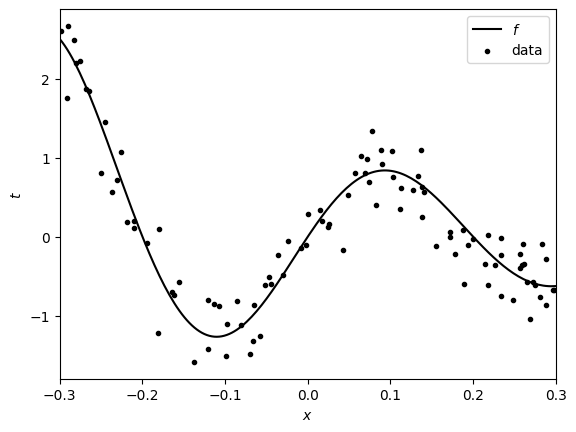

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def f(x):
    return np.sin(5*np.pi*x)/(1+2*x)

def make_additive_noise_data(n, f, a, b, noise=0.1**0.5, random_state=None):
    RNG = np.random.default_rng(random_state)
    x = RNG.uniform(a, b, size=(n, 1))
    y = f(x) + RNG.normal(0, noise, size=(n, 1))
    return x, y

def plot_function(f, a, b, models=[], data=None, ax=None, ax_labels=True, legend=True):
    ax = plt.gca() if ax is None else ax
    xx = np.linspace(a, b, 200).reshape(-1, 1)
    if len(models)==1:
        ax.fill_between(xx.squeeze(), f(xx).squeeze(), models[0].predict(xx).squeeze(), alpha=0.3)
        ax.plot(xx, models[0].predict(xx), label='$y$')
    if len(models) > 1:
        for model in models: ax.plot(xx, model.predict(xx), color='gray', alpha=0.5)
    ax.plot(xx, f(xx), color='black', label='$f$')
    if data is not None:
        x, y = data
        ax.scatter(x, y, marker='.', color='black', label='data')
    if ax_labels:
        ax.set_xlabel('$x$')
        ax.set_ylabel('$t$')
    if legend: ax.legend()
    ax.margins(x=0)

plot_function(f, -0.3, 0.3, data=make_additive_noise_data(100, f, -0.3, 0.3, random_state=0))
plt.show()

In the lecture, we discussed that the mean (expected) squared error of a predictive regression model $\mathbf{E}(T-y(X))^2$ with prediction function $y$ can be decomposed into a sum of two terms
\begin{equation*}
\mathbf{E}(T-y(X))^2 = \underbrace{\mathbf{E}(h(X)-y(X))^2}_\text{reducible error} + \underbrace{\mathbf{E}((T - h(X))^2}_\text{irreducible error} \enspace .
\end{equation*}
Here, the first term is the mean squared deviation of the prediction function from the **regression function** $h(x)=\mathbf{E}(T | X=x)$, i.e., the conditional expectation of $T$ given $X=x$, which can be reduced to $0$ in the ideal case that the prediction function is equal to the regression function.
In contrast, the second term, i.e., the conditional variance of the target given the input variable, is a constant determined by the joint distribution of $X$ and $T$ and can not be reduced by the model.

#### Task A: What is the regression function and what is the irreducible error for our example?

**Give a brief answer and test your hypothesis by computing the approximated mean squared error of the regression function using a large data sample.**

In [3]:
x_test, y_test = make_additive_noise_data(100000, f, -0.3, 0.3, random_state=0)
((y_test - f(x_test))**2).mean()

np.float64(0.10047902700180152)

After having computed the irreducible part of the mean squared error, we can now go ahead and compute the reducible part for our first model, which we choose to be a simple a linear model, i.e., only using the single linear input feature and an offset (intercept) term.

Having implemented the linear model already in previous activities, we can now take the convenient route and import it from `sklearn.linear_model`.

Let us start with using the test set to estimate the overall mean squared error (generalisation error) of the model.

In [4]:
from sklearn.linear_model import LinearRegression

x_train, y_train = make_additive_noise_data(20, f, -0.3, 0.3, random_state=1)
linear = LinearRegression().fit(x_train, y_train)
((y_test - linear.predict(x_test))**2).mean()

np.float64(1.023477023787717)

By our previous considerations, the mean squared error computed above should be the irreducible error plus the mean squared deviation of the prediction function from the regression function (which is $f$ in our case). Let us plot the prediction function and color the deviation from regression function.

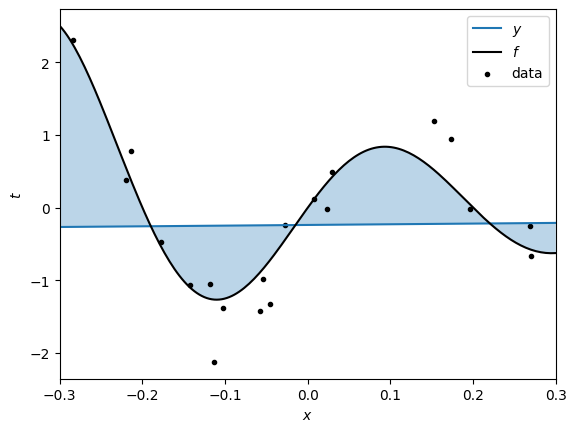

In [5]:
plot_function(f, -0.3, 0.3, [linear], (x_train, y_train))

#### **Task B: Compute the Reducible Error, i.e., the Mean Squared Deviation from Regression Function**

**Approximate the reducible error of our fitted prediction function $y$, i.e., mean squared deviation from the regression function, $\mathbf{E}((h(X)-y(X))^2)$, and see if adds up together with the irreducible error to the mean squared error of the model as computed above.**

Implementation notes: 

- The fitted prediction function is here given by `linear.predict`. Do you recall what is the regression function in our example?
- Instead of computing the integral, we are simply averaging the sum of squared deviations over a fine test grid of points taking equi-distantly over the whole domain of the function (`x_all`). Such a grid can be generated by the function [`numpy.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html).
- A small issue with the grid computed by `linspace` is that it is a 1-d array, and the `predict`-methods in `scikit-learn` expect a 2-d array (data matrix) as input. Thus, we have to convert our shape `(n)` grid into a shape `(n, 1)` matrix or column vector. Here, the `n` stands for the number of grid points we have generated. We can do this with the [`reshape`](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) method of the array. Note how in the code below, we use `-1` in place of the actual number of grid points. This "wild card" can be used by the reshape method for one of the output dimensions, and `numpy` will automatically determine the right number for us.

In [7]:
x_all_grid = np.linspace(-0.3, 0.3, 3000)
x_all = x_all_grid.reshape(-1, 1)
((f(x_all) - linear.predict(x_all))**2).mean()

np.float64(0.9189025575401556)

***

### **Polynomial Feature Expansion, Transformations, and Pipelines**

To fit the data distribution better, we are now adding a polynomial basis function expansion to our linear model. That is, we implement the feature transformation
\begin{equation*}
\boldsymbol{\phi}(x) = (1, x, x^2, \dots, x^d)
\end{equation*}
for different degrees $d$. In `scikit-learn` such transformations are represented by `Transformer` objects (not to be confused with the Deep Learning architecture of the same name) that are very similar to the `Estimator` objects that represent predictive models. In particular, data transformations are also used in three steps,

1. **define**, implemented again in the `__init__`-method, where the non-data-dependent parameters of the transformation are set,
2. **fit** implemented in `fit(x, y)`, where data-dependent parameters of the transformation are learned (think, e.g., about data normalisations based on the sample standard deviation)
3. **transform** implemented in `transform(x, y)`, where the transformation is applied to data.

Additonally, the transformations provide a convenience method `fit_transform(x, y)`, which, as the name suggests, first fits the transformation parameters to the given data and than directly uses them to transform the same data.

#### Task C: Implement polynomial features

**Finish the implementation of the polynomial feature expansion below. Note: we assume one dimensional data here, which makes this transformation very simple (and not require any data-dependent fitting).**

Implementation notes:

- As illustration, a simple example input for transform could be `a=np.array([[1.0], [2.0], [3.0]])`. The output for `PolynomialFeatures(3).transform(a)` should then be `array([[ 1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8.],
       [ 1.,  3.,  9., 27.]])`
- The scaffold code below generates one column of the tranformed data matrix at a time and adds it to a Python list. in the end we have to turn all these individual columns into one output matrix. We can do this using [`numpy.column_stack`](https://numpy.org/doc/stable/reference/generated/numpy.column_stack.html).


In [9]:
class PolynomialFeatures:

    def __init__(self, degree):
        self.degree = degree

    def fit(self, x, y=None):
        return self

    def transform(self, x, y=None):
        output = []
        for i in range(0, self.degree+1):
            column = np.asarray(x).reshape(-1) ** i
            output.append(column)
        return np.column_stack(output)

    def fit_transform(self, x, y=None):
        self.fit(x, y)
        return self.transform(x, y)
    
# Test
PolynomialFeatures(3).transform(np.array([1.0, 2.0, 3.0]))


array([[ 1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8.],
       [ 1.,  3.,  9., 27.]])

In [10]:
poly = PolynomialFeatures(3)
poly.transform(x_train)

array([[ 1.00000000e+00,  7.09297482e-03,  5.03102918e-05,
         3.56849633e-07],
       [ 1.00000000e+00,  2.70278218e-01,  7.30503150e-02,
         1.97439090e-02],
       [ 1.00000000e+00, -2.13504232e-01,  4.55840572e-02,
        -9.73238915e-03],
       [ 1.00000000e+00,  2.69189668e-01,  7.24630775e-02,
         1.95063118e-02],
       [ 1.00000000e+00, -1.12901129e-01,  1.27466649e-02,
        -1.43911285e-03],
       [ 1.00000000e+00, -4.60041306e-02,  2.11638003e-03,
        -9.73622235e-05],
       [ 1.00000000e+00,  1.96621556e-01,  3.86600364e-02,
         7.60139652e-03],
       [ 1.00000000e+00, -5.44805182e-02,  2.96812686e-03,
        -1.61705089e-04],
       [ 1.00000000e+00,  2.97562126e-02,  8.85432189e-04,
         2.63471084e-05],
       [ 1.00000000e+00, -2.83464532e-01,  8.03521409e-02,
        -2.27769820e-02],
       [ 1.00000000e+00,  1.52107865e-01,  2.31368027e-02,
         3.51928966e-03],
       [ 1.00000000e+00,  2.28859879e-02,  5.23768444e-04,
      

Good, we can now use this transformation to fit a third degree polynomial to our training data and see if this improves the squared error. Note how the feature transformation already adds a constant 1-term. Hence, we do not need to fit a separate intercept anymore.

#### Task D: Use transformed features for prediction

**Complete the line below to use our new model to predict values for the input points `x_all`.**

In [12]:
from sklearn.linear_model import LinearRegression

x_train, y_train = make_additive_noise_data(20, f, -0.3, 0.3, random_state=1)

linear2 = LinearRegression(fit_intercept=False)
linear2.fit(poly.transform(x_train), y_train)

y_all_hat = linear2.predict(poly.transform(x_all))
((f(x_all) - y_all_hat)**2).mean()

np.float64(0.149559219739291)

Great. This was a massive improvement over the linear features. Before investigating the effect of the polynomial degree in more detail, let us fix the inconvience of always having to remember to apply the transformation to the test data (which you might have stumbled over when solving the last task). 

Indeed, it would be much better, if we could simply define a new model (`scikit-learn` Estimator) that combines the transformation and the predictive model in one object. In `scikit-learn` this can be done by creating [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline) objects. You can create pipeline by using that type directly, but in this case you have to name each part of the pipeline, which is not necessary for simple applications.

The most convenient way is to use the function `sklearn.pipeline.make_pipeline` as demonstrated below.



In [13]:
from sklearn.pipeline import make_pipeline

transformation_then_linear = make_pipeline(poly, LinearRegression(fit_intercept=False))
transformation_then_linear.fit(x_train, y_train).predict(x_train)

array([[-0.29501317],
       [-0.60761658],
       [ 0.02665079],
       [-0.57526271],
       [-1.17543909],
       [-0.86026179],
       [ 0.77002579],
       [-0.93159905],
       [-0.02436739],
       [ 2.69183476],
       [ 0.9435247 ],
       [-0.10657431],
       [-1.16960393],
       [ 0.91284288],
       [-1.17078232],
       [-0.6866682 ],
       [ 0.18908304],
       [-0.96007313],
       [-0.69775043],
       [-1.07605665]])

This combined object can now be passed around freely and none of its callers has to know/remember that it internally performs a transformation. This allows us, for instance, to use it with our previously defined plotting function.

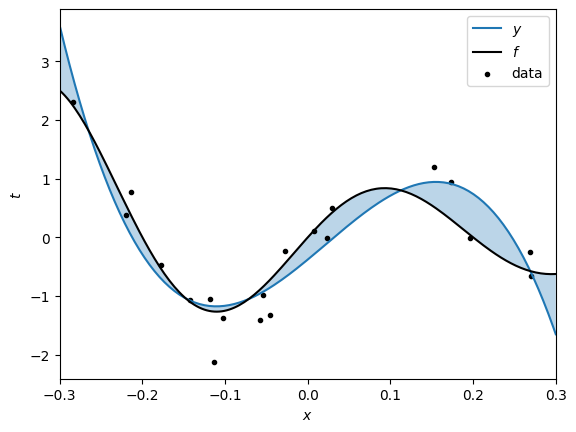

In [14]:
plot_function(f, -0.3, 0.3, [transformation_then_linear], data=(x_train, y_train))
plt.show()

#### **Task E: Define linear model with transformations**

Now let us systematically fit polynomial feature models for all degrees from 1 to 15.

**Complete the code below to create a linear model with polynomial feature expansion of degree `d` within the loop. Hint: Remember what `scikit-learn` construct we used for this.**

In [17]:
degrees = np.arange(1, 16)
models = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression(fit_intercept=False))
    model.fit(x_train, y_train)
    models.append(model)

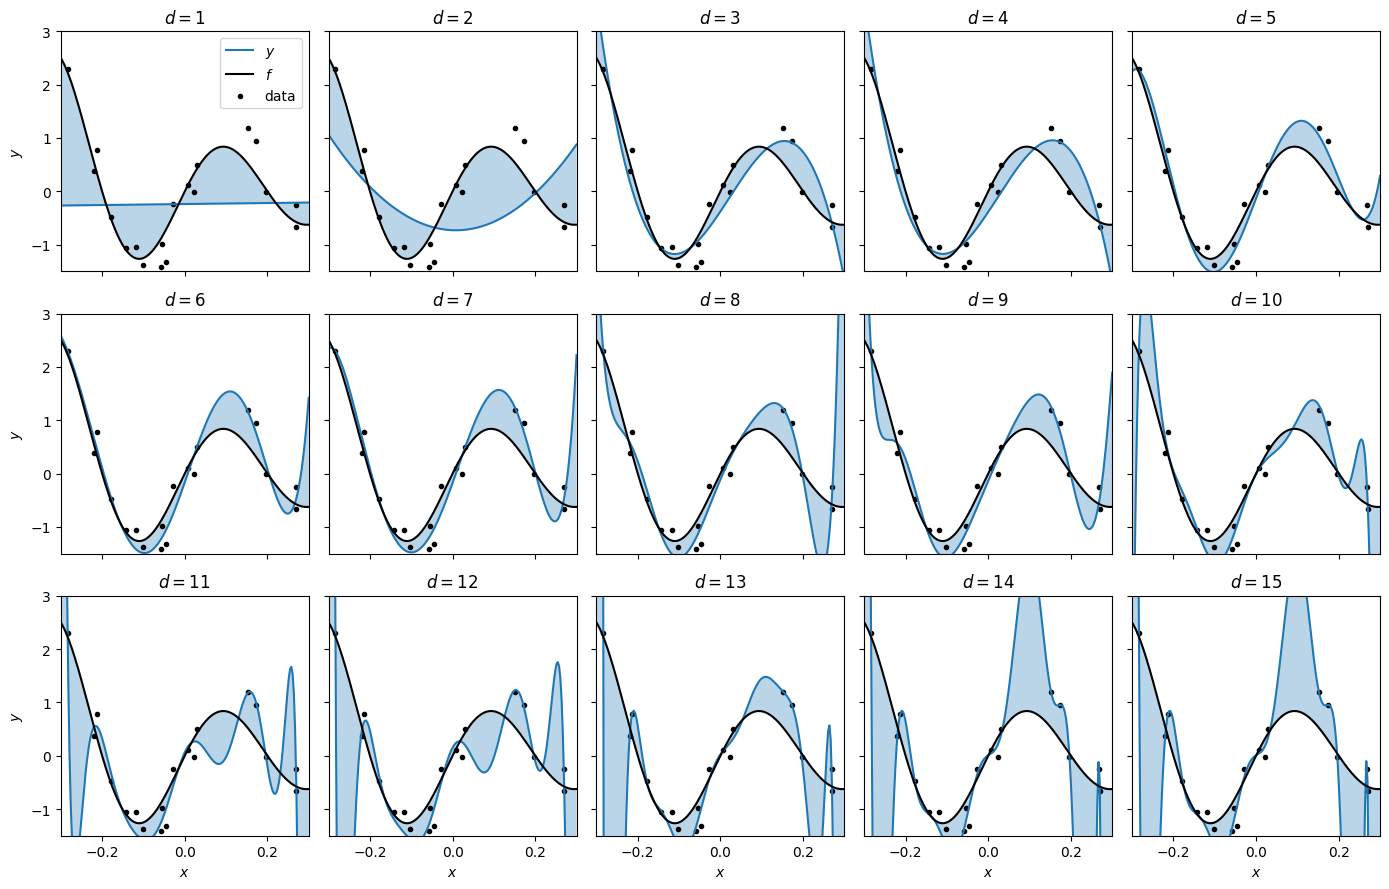

In [18]:
_, axs = plt.subplots(3, 5, tight_layout=True, sharex=True, sharey=True, figsize=(14, 9))
for i, model in enumerate(models):
    ax = axs[i//5][i%5]
    plot_function(f, -0.3, 0.3, [model], (x_train, y_train), legend=False, ax_labels=False, ax=ax)
    ax.set_title(f'$d={degrees[i]}$')
axs[0, 0].set_ylim(-1.5, 3)
axs[0, 0].legend()
for i in range(3): axs[i, 0].set_ylabel('$y$')
for j in range(5): axs[2, j].set_xlabel('$x$')
plt.show()

#### **Task F: Summarize the figure**

**Summarise the above figure in a few sentences using the terminology of underfitting and overfitting, pointing out the meaning of the terms.**

**Answer:** At low degrees ($d=1,2$) the model is too simple to capture the curve's shape — this is underfitting: the fit misses the true function $f$ almost everywhere, giving high error on both train and unseen data. Around $d=3$–$7$ the polynomial captures the two humps of $f$ reasonably well and stays close to it across the domain — a good balance of flexibility and stability. From about $d=8$ onward, the model starts chasing the noise in the 20 training points, producing wild oscillations near the edges of the domain where data is sparse — this is overfitting: the fit matches the training points almost perfectly but deviates wildly from $f$ elsewhere, meaning it will generalise poorly to new data. 

*** 

### **Finding the Optimal Degree: Bias/Variance Decomposition**

From the above visualisation, we get a clear impression that the higher degree polynomials as well as the degrees of one and two are not a good choice for the prediction problem represented by our data generator (at least using a training size of 20). To figure out the optimal choice from the remaining degrees it is risky to only rely on one fit, i.e., only one set of training data.

As explained in the lecture, ultimately we are interested in understanding how well a model will perform on average, i.e., in terms of the expectation 

$$
    \mathbf{E}(h(X)-y(X, D))^2 \enspace ,
$$ 

where that expectation takes into account the randomness of the training data $D$. To answer this question, since we have a data generator, we can just rerun the above experiment for a number of repetitions $R$ with independently sampled training sets $D_1, \dots, D_R$. We can then approximate the above expectation via 
$$
    \sum_{g=1}^G \frac{1}{G} \sum_{r=1}^R \frac{1}{R} (h(x_g)-y(x_g, D_r))^2 
$$ 
where $x_1, \dots, x_G$ are again the regular grid of test data points.

In [19]:
from collections import defaultdict

models_rep = defaultdict(list)
reps = 200

for r in range(reps):
    x_train, y_train = make_additive_noise_data(20, f, -0.3, 0.3)
    for d in degrees:
        model = make_pipeline(PolynomialFeatures(d), LinearRegression())
        model.fit(x_train, y_train)
        models_rep[d].append(model)

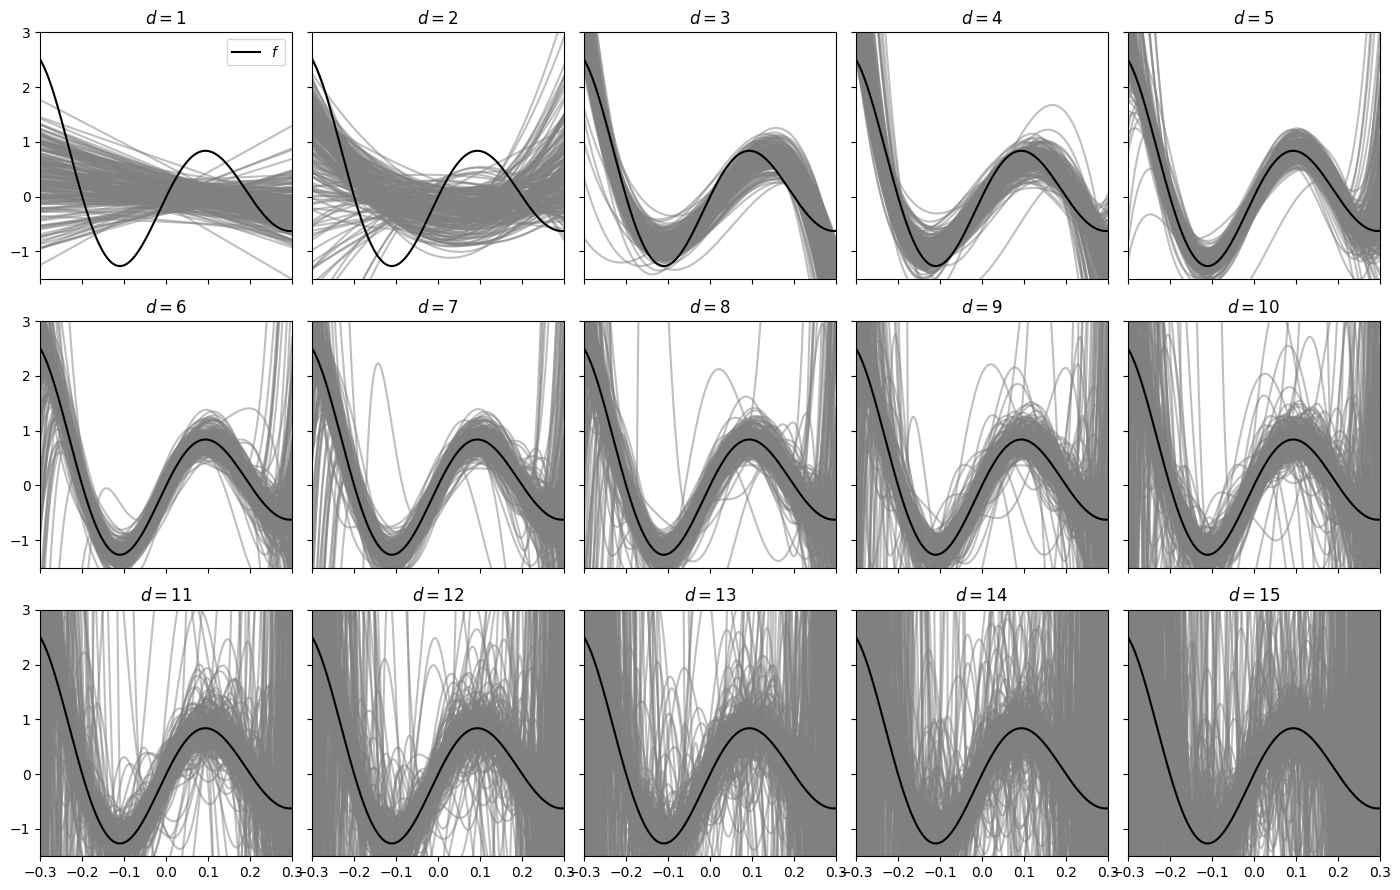

In [20]:
_, axs = plt.subplots(3, 5, tight_layout=True, sharex=True, sharey=True, figsize=(14, 9))
for i, d in enumerate(degrees):
    ax = axs[i//5][i%5]
    plot_function(f, -0.3, 0.3, models_rep[d][:200], legend=False, ax_labels=False, ax=ax)
    ax.set_title(f'$d={degrees[i]}$')
axs[0, 0].set_ylim(-1.5, 3)
axs[0, 0].legend()
plt.show()

#### **Task G: Visually assess the performance of the different polynomial degrees**

**Which of the degrees would you recommend using based on the figure above?**

**Answer:** $d=5$ or $d=6$. At these degrees the bundle of fitted curves stays tightly clustered around the true function $f$ across the whole domain — low spread (low variance) and the average closely tracks $f$ (low bias). Degrees 1–2 are systematically off from $f$ (underfitting/high bias), while degrees 8 and above show increasingly wide, erratic spread between individual fits, especially near the edges (overfitting/high variance).

Now let us check whether your assessment is confirmed by approximately computing the expected squared deviation and plot them against the degrees.

In [21]:
predictions = np.zeros(shape=(len(degrees), reps, len(x_all)))

for i, d in enumerate(degrees):
    for r, model in enumerate(models_rep[d]):
        predictions[i, r, :] = model.predict(x_all).squeeze()

In [22]:
mean_squared_deviations = ((predictions - f(x_all).squeeze())**2).mean(axis=1).mean(axis=1)
mean_squared_deviations

array([8.81884271e-01, 9.03505563e-01, 1.97030903e-01, 3.24254637e-01,
       1.74369490e-01, 1.51527636e+00, 2.08002915e+01, 6.19704575e+02,
       4.95264058e+03, 1.06405527e+06, 6.67375939e+05, 7.45967211e+07,
       1.97638125e+11, 2.23193935e+11, 1.54225284e+11])

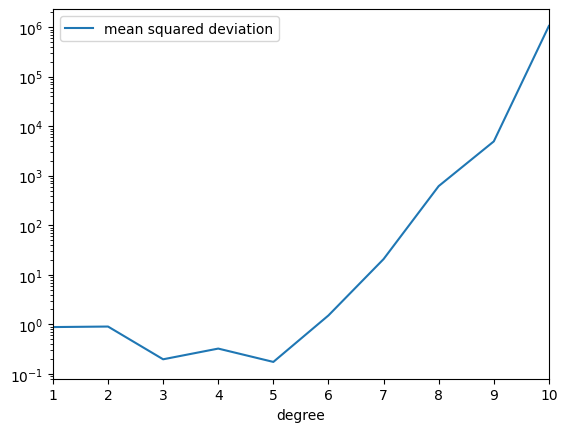

In [23]:
plt.plot(degrees[:10], mean_squared_deviations[:10], label='mean squared deviation')
plt.yscale('log')
plt.margins(x=0)
plt.xlabel('degree')
plt.legend()
plt.show()

Does this graph confirm your assessment? If not you might have underestimated the *variance* for the higher degrees. Recall that in the lecture we decomposed the expected squared deviation $\mathbf{E}(h(X)-y(X))^2$ further into two terms:
\begin{equation*}
\mathbf{E}(h(X)-y(X))^2 = \underbrace{\mathbf{E}(h(X)-\mu_y(X))^2}_\text{squared bias} + \underbrace{\mathbf{E}(y(X)- \mu_y(X))^2}_\text{variance} \enspace .
\end{equation*}
The first term represents how well a model fits the regression function *on average*. Whereas the second term quantifies how reliably this average represents an individual fit. We close this activity by approximately computing these two terms and use this for a final analysis.

We start by computing and plotting the mean prediction function for all degrees.

In [24]:
means = np.zeros(shape=(len(degrees), len(x_all)))

for i in range(len(degrees)):
    means[i, :] = predictions[i, :, :].mean(axis = 0)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38780\2415306169.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_all, means[i, :], color='red', label='$\mu_y$')


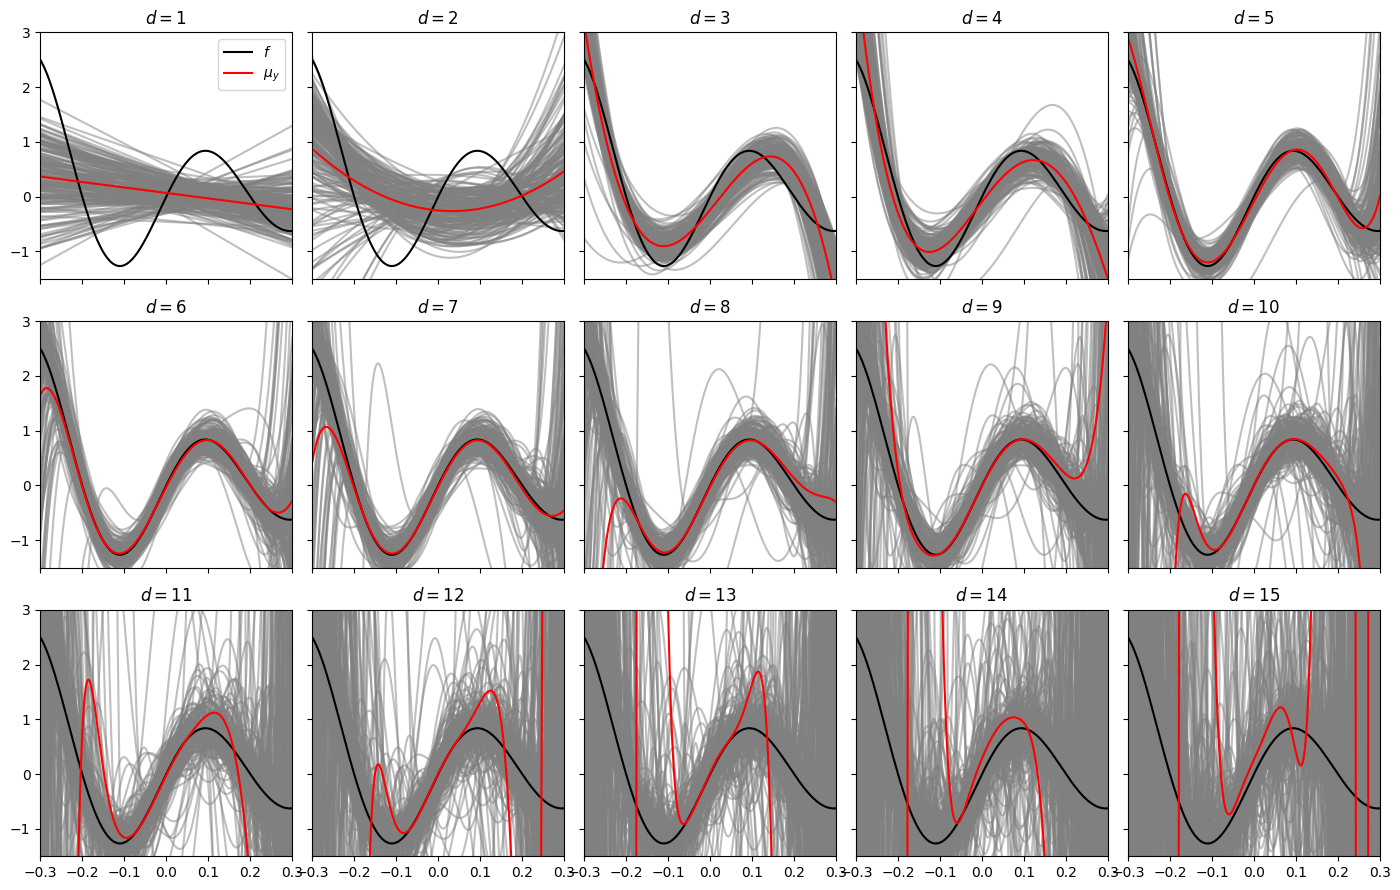

In [25]:
_, axs = plt.subplots(3, 5, tight_layout=True, sharex=True, sharey=True, figsize=(14, 9))
for i, d in enumerate(degrees):
    ax = axs[i//5][i%5]
    plot_function(f, -0.3, 0.3, models_rep[d], legend=False, ax_labels=False, ax=ax)
    ax.plot(x_all, means[i, :], color='red', label='$\mu_y$')
    ax.set_title(f'$d={degrees[i]}$')
    ax.margins(x=0)
axs[0, 0].set_ylim(-1.5, 3)
axs[0, 0].legend()
plt.show()

From this we can compute the bias squared and variance terms of the individual degrees. Do you understand the below `numpy` code? Do not be discouraged if not. This uses the more advanced broadcasting rules. As usual, you could alternatively compute those using loops (it would just be much slower).

In [26]:
biases = ((means - f(x_all).squeeze())**2).mean(axis=1)
variances = ((predictions.swapaxes(0, 1) - means)**2).mean(axis=0).mean(axis=1)

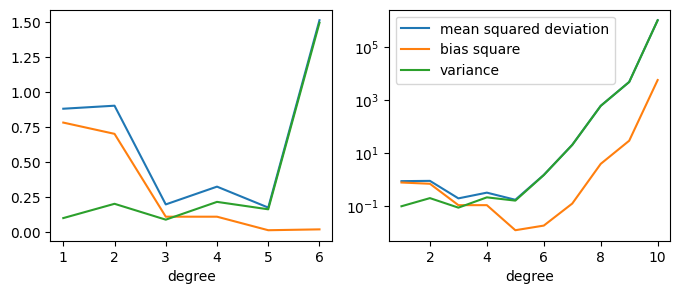

In [27]:
_, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].plot(degrees[:6], mean_squared_deviations[:6], label='mean squared deviation')
axs[0].plot(degrees[:6], biases[:6], label='bias square')
axs[0].plot(degrees[:6], variances[:6], label='variance')
axs[0].set_xlabel('degree')
axs[1].plot(degrees[:10], mean_squared_deviations[:10], label='mean squared deviation')
axs[1].plot(degrees[:10], biases[:10], label='bias square')
axs[1].plot(degrees[:10], variances[:10], label='variance')
axs[1].set_yscale('log')
axs[1].set_xlabel('degree')
axs[1].legend()
plt.show()

### **Conclusion**

#### Task H: Summarise what you have learned

**What does the bias/variance analysis reveal?**

**Answer:** It confirms the bias-variance tradeoff directly: bias is high for low-degree (too simple) models and shrinks as degree increases, while variance is low for simple models and grows sharply as degree increases (too flexible, fits noise). The total expected squared error is minimized at an intermediate degree (~5–6) where both terms are small, rather than at the extremes.

**Do you think that the increasing bias from degree six on is a real phenomenon or is this likely due to an estimation error? Why?**

**Answer:** Likely estimation error, not a true effect. With only 200 repetitions and just 20 training points, the estimated mean prediction $\mu_y(x)$ used to compute bias is itself noisy — especially for higher-degree models whose individual fits vary wildly. That noise in estimating $\mu_y$ leaks into the squared-bias calculation, inflating it slightly, even though a more flexible model shouldn't actually become more biased.

**How would you expect these results to change when we increase the training size from 20 to 100 data points?**

**Answer:** Variance would decrease substantially at every degree, since more data points constrain the fit more tightly (less room to chase noise), while bias would stay roughly the same (it's a function of model flexibility, not sample size). Consequently, the optimal degree would likely shift higher than 5–6, since higher-degree polynomials could now be fit reliably without variance exploding as fast.